1. Write a BankAccount class that satisfies all of the following:
- Stores the account holder's name and balance.
- Prevents direct modification of the balance.
- Provides deposit() and withdraw() methods.
- Raises a custom InsufficientFundsError if the balance is insufficient.
- Maintains a transaction history.
- Implements __str__() to display account details.

In [2]:
class InsufficientFundsError(Exception):
   pass

class BankAccount:
     def __init__(self, name, balance):
            self.name = name 
            self.__balance = balance
            self.history = []

     @property
     def balance(self):
        return self.__balance

     def deposit(self, amount):
        if amount <= 0:
            raise ValueError("Deposit amount must be positive")

        self.__balance += amount
        self.history.append(f"Deposited {amount}")

     def withdraw(self, amount):
        if amount > self.__balance:
            raise InsufficientFundsError("Insufficient balance")

        self.__balance -= amount
        self.history.append(f"Withdrew {amount}")

     def __str__(self):
        return f"{self.name} | Balance: {self.__balance}"

In [3]:
account = BankAccount("Orbin", 1000000)

print(account)

account.deposit(50000)
print(account.balance)

account.withdraw(599)
print(account.balance)

print(account.history)

try: 
    account.deposit(-100)
except ValueError as e:
    print(e)

try:
    account.withdraw(1999999999)
except InsufficientFundsError as e:
    print(e)


Orbin | Balance: 1000000
1050000
1049401
['Deposited 50000', 'Withdrew 599']
Deposit amount must be positive
Insufficient balance


2. Write a decorator called log_execution that:
- Can decorate any function.
- Prints the function name before execution.
- Measures and prints the execution time.
- Logs any exception raised by the function.
- Preserves the original function's metadata.

In [5]:
import time 
from functools import wraps 

def log_execution(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        print(f"Executing: {func.__name__}")

        start = time.perf_counter()

        try:
            result = func(*args, **kwargs)
            return result 

        except Exception as e:
            print(f"Exception: {e}")
            raise 

        finally:
            end = time.perf_counter()
            print(f"Excecution Time: {end - start:.6f} seconds")
    return wrapper 

@log_execution
def add(a, b):
    return a+b

@log_execution
def divide(a, b):
    return a/b 

print(add(5, 10))
print(divide(10, 2))


Executing: add
Excecution Time: 0.000001 seconds
15
Executing: divide
Excecution Time: 0.000001 seconds
5.0


You are given an orders.csv file containing:
- order_id
- customer_id
- product
- category
- quantity
- unit_price
- order_date
- region

Using Pandas, explain or write code to:
- Load and inspect the dataset.
- Convert order_date to a proper datetime type.
- Remove duplicate orders.
- Handle missing values appropriately.
- Create a total_sales column.
- Calculate total and average sales for each category.
- Identify the top 5 customers by total sales.
- Calculate monthly sales.
- Export the cleaned dataset and summaries.

In [ ]:
import pandas as pd 

df = pd.read_csv('orders.csv')
df.info()

df.describe()

df.isnull().sum()

df = df.drop_duplicates(inplace=True)

df.fillna(df).mean()

In [ ]:
import pandas as pd 

df = pd.read_csv("orders.csv")

print(df.head())
print(df.info())
print(df.describe())

# Covert date column 
df['order_data'] = pd.to_datetime(df['order_date'])



Generate a reproducible dataset containing 1,000 normally distributed examination scores.
- Clip invalid values so all scores are between 0 and 100.
- Calculate:Mean
    - Median
    - Standard deviation
    - Minimum
    - Maximum
    - Percentiles

- Identify scores more than 2 standard deviations from the mean.
- Plot a histogram with the mean and median marked.
Create a box plot to detect possible outliers.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.Dataframe([x for x in np.random.randint(1000, 0, 100)], columns=['scores'])

mean = df.means()
median = np.linalg.med(df)
standard_deviation = np.linalg.med(df)
min = df.min()
max = df.max()

plt.hist(mean, median)
plt.boxplot(df['scores'])

AttributeError: module 'pandas' has no attribute 'Dataframe'

## Question 1 — Custom Iterator (Very High Probability ⭐⭐⭐⭐⭐)

Create a custom iterator class named `EvenNumbers` that generates all even numbers starting from **2** up to a specified maximum value `max_value`.

Requirements:

- Implement `__iter__()` and `__next__()`.
- Stop iteration correctly using `StopIteration`.
- Demonstrate the iterator using a `for` loop.

Example:

```
obj = EvenNumbers(10)

Output:
2
4
6
8
10
```

In [10]:
class EvenNumbers:
    def __init__(self, maxvalue):
        self.maxvalue=maxvalue
        self.current = 2

    def __iter__(self):
        return self 

    def __next__(self):
        if self.current > self.maxvalue:
            raise StopIteration

        value = self.current 
        self.current += 2

        return value 

obj = EvenNumbers(10)

for num in obj:
    print(num)

2
4
6
8
10


In [12]:
val = 10
for num in [x for x in range(2, val+1, 2)]:
    print(num)

2
4
6
8
10


LeetCode 83 – Remove Duplicates from Sorted List

Difficulty: Easy

The interviewer is testing:
Linked List traversal
Pointer manipulation
Understanding of sorted lists
Time Complexity

In [22]:
class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next

In [23]:
class Solution:
    def deleteDuplicates(self, head):
        current = head

        while current and current.next:
            if current.val == current.next.val:
                current.next = current.next.next
            else:
                current = current.next

        return head



In [24]:
head = ListNode(1)
head.next = ListNode(1)
head.next.next = ListNode(2)
head.next.next.next = ListNode(3)
head.next.next.next.next = ListNode(3)

solution = Solution()
result = solution.deleteDuplicates(head)

In [25]:
while result:
    print(result.val)
    result = result.next 

1
2
3


## Question 1 — Eigenvalues and Eigenvectors

**Very High Probability ⭐⭐⭐⭐⭐**

Using NumPy, write a Python program to find the **eigenvalues and eigenvectors** of the following matrix:

```
A = np.array([
    [4, 2],
    [1, 3]
])
```

Requirements:

- Display the original matrix.
- Calculate its eigenvalues.
- Calculate its corresponding eigenvectors.
- Verify one eigenvalue and eigenvector using:

```
A @ v = λ * v
```

This is the most likely question because the same concept appeared in your previous test.

In [26]:
import numpy as np 

A = np.array([
    [4, 2],
    [1, 3]
])

print(A)

[[4 2]
 [1 3]]


In [27]:
eigenvalues, eigenvectors = np.linalg.eig(A)

lambda_1 = eigenvalues[0]
v1 = eigenvectors[:, 0]

In [28]:
left_side = A @ v1
righ_side = lambda_1 * v1
print("A x v = ", left_side)
print("lambda x v = ", righ_side)
print("Verified: ", np.allclose(left_side, righ_side))

A x v =  [4.47213595+0.j 2.23606798+0.j]
lambda x v =  [4.47213595+0.j 2.23606798+0.j]
Verified:  True


## Question 1 — End-to-End Classification using Titanic Dataset (Very High Probability ⭐⭐⭐⭐⭐)

**Task:**

Using the Titanic dataset, create a Jupyter Notebook that demonstrates the complete Machine Learning workflow for predicting passenger survival.

### Requirements

1. Load the Titanic dataset.
2. Perform Exploratory Data Analysis (EDA).
    - Display dataset information.
    - Check missing values.
    - Visualize the target distribution.
3. Perform Data Cleaning.
    - Handle missing values.
    - Remove duplicates (if any).
4. Perform Feature Engineering.
    - Encode categorical variables.
    - Scale numerical features where necessary.
    - Select useful features.
5. Split the dataset into training and testing sets.
6. Build a classification model using **Random Forest Classifier**.
7. Perform hyperparameter tuning using **GridSearchCV**.
8. Evaluate the model using:
    - Accuracy
    - Precision
    - Recall
    - F1-Score
    - Confusion Matrix
    - Classification Report
9. Display the best hyperparameters and final model performance.
10. Briefly conclude the results.


In [29]:
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report, 
    ConfusionMatrixDisplay
)

In [31]:
# Load the dataset 
df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [33]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [34]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df = df.drop_duplicates()

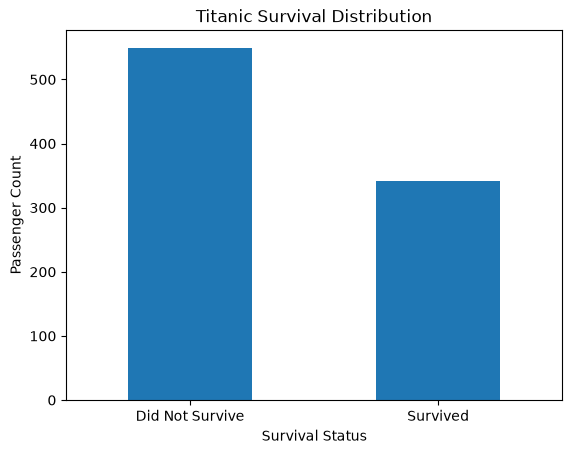

In [37]:
df['Survived'].value_counts().sort_index().plot(kind='bar')

plt.title("Titanic Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Passenger Count")
plt.xticks([0, 1], ["Did Not Survive", "Survived"], rotation=0)
plt.show()

In [38]:
features = ["Pclass", "Sex",	"Age",	"SibSp", 	"Parch"	,	"Fare"	,	"Embarked"]

X = df[features]
y = df["Survived"]

In [39]:
numerical_features = ["Age","SibSp", 	"Parch"	,	"Fare"]
cat_features = ["Pclass", "Sex","Embarked"]

In [40]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [41]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

In [43]:
categorical_pipeline = Pipeline([
    ("inmputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

In [44]:
# Preprocessing
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, cat_features),
])

In [ ]:
# Full Pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

In [46]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

In [47]:
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid,
    cv=5, 
    scoring="f1",
    n_jobs=-1
)

In [50]:
grid_search.fit(X_train, y_train)

python(66560) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66562) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66563) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66564) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66565) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66566) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66567) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66568) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66569) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(66570) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable ad

In [51]:
print(grid_search.best_params_)

print(grid_search.best_score_)

{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}
0.7477520659694573


In [52]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [53]:
# Evaluation Scores
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy: ", round(accuracy, 4))
print("Precision: ", round(precision, 4))
print("Recall: ", round(recall, 4))
print("F1: ", round(f1, 4))

Accuracy:  0.7989
Precision:  0.7463
Recall:  0.7246
F1:  0.7353


In [54]:
# Classification Report 
print(classification_report(
    y_test, 
    y_pred,
    target_names=["Did Not Survive", "Survived"],
))

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.85      0.84       110
       Survived       0.75      0.72      0.74        69

       accuracy                           0.80       179
      macro avg       0.79      0.79      0.79       179
   weighted avg       0.80      0.80      0.80       179



In [55]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[93 17]
 [19 50]]


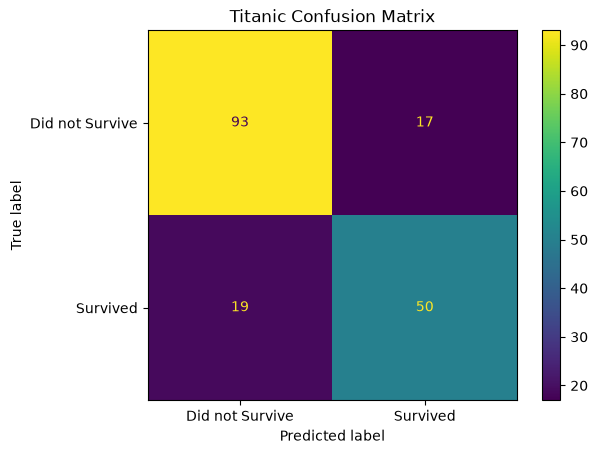

In [56]:
ConfusionMatrixDisplay(confusion_matrix=cm, 
                       display_labels=["Did not Survive", "Survived"]).plot()

plt.title("Titanic Confusion Matrix")
plt.show()

In [57]:
!pip install django djangorestframework

python(72664) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 2.4 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.1/899.1 kB 2.1 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [djangorestframework]angorestframework]
